In [22]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import emcee
from seaborn import kdeplot

In [117]:
a = 2
b = 0.1
sigma_x = 1

def log_dens(u):
    y = -1.0
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return -scale * sum_part

In [127]:
np.random.seed(39)
initial = np.random.randn(4, 1)
nwalkers, ndim = initial.shape
nsteps = 4 ** 8

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_dens)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 65536/65536 [00:07<00:00, 8551.95it/s]


In [128]:
np.vstack(sampler.chain)

array([[2.07344018],
       [2.07344018],
       [2.16449686],
       ...,
       [0.84330858],
       [0.81995309],
       [2.4092504 ]], shape=(262144, 1))

<Axes: ylabel='Density'>

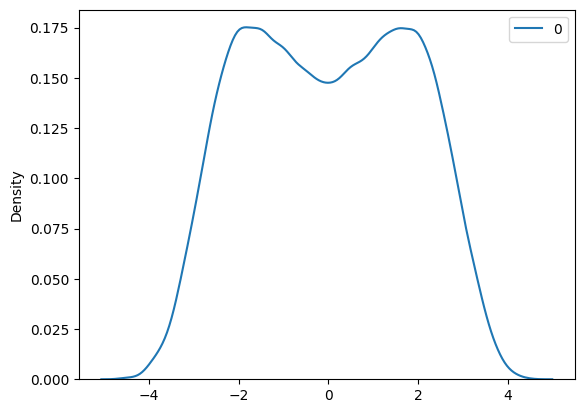

In [125]:
kdeplot(np.vstack(sampler.chain))

In [75]:
mcmc_samps = np.load("mcmc_results/mcmc_results_5/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_5/cond_vars_1.npy")

<Axes: ylabel='Density'>

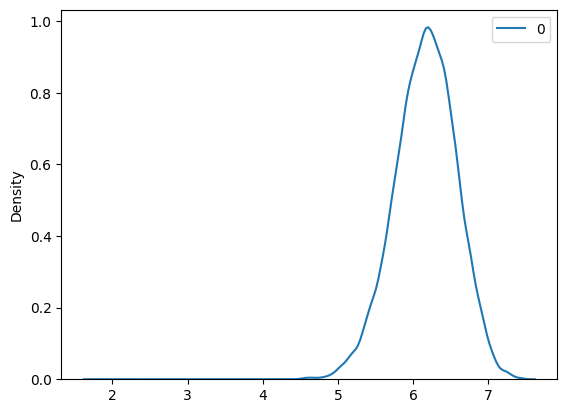

In [74]:
kdeplot(mcmc_samps)

In [82]:
cond_var

array([-4.55791761])